# Wasserstein Regime Clustering

**Docker image**: `ml4t`

This notebook implements the methodology from **"Clustering Market Regimes Using the
Wasserstein Distance"** (Horvath et al., 2021). Instead of clustering
on moment features (mean, variance, skewness), each time window is treated as an
empirical distribution and clustered using optimal transport.

**Learning Objectives**:
- Understand Wasserstein distance as a distributional similarity metric
- Implement stream-lift partitioning and empirical measure construction
- Apply Wasserstein k-means with barycenter centroids
- Extract regime features: `wasserstein_cluster`, `cluster_distance`, `tail_divergence`

**Book Reference**: Chapter 9, Section 9.5 (Regime Features)

**Prerequisites**: `11_hmm_regimes` for parametric regime detection (HMM);
this notebook provides a non-parametric alternative.

In [1]:
"""Wasserstein Regime Clustering — detect market regimes using optimal transport distance."""

import warnings

warnings.filterwarnings("ignore")

import math
import time
from collections.abc import Mapping, Sequence
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from ml4t.diagnostic.evaluation.drift import compute_psi, compute_wasserstein_distance
from numpy.typing import NDArray
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from data import load_sp500_index
from utils.reproducibility import set_global_seeds

In [2]:
WINDOW_LEN = 21
OVERLAP = 5
N_STEPS = 2000
MMD_BOOTSTRAPS = 200
SEED = 42

In [3]:
set_global_seeds(SEED)
RANDOM_STATE = SEED

## Configuration

In [4]:
# Clustering
N_CLUSTERS = 2  # Risk-on vs Risk-off

# Wasserstein exponent (p=1 for L1, p=2 for L2)
WASSERSTEIN_P = 1.0

# MMD validation
MMD_SIGMA = 0.1

## Part 1: Core Implementation

### Stream Lift Function

The stream lift transforms a return series into overlapping windows. Each window
becomes an empirical distribution that we can cluster.

In [5]:
FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]


@dataclass(frozen=True)
class LiftedStream:
    """Representation of a lifted return stream."""

    segments: FloatArray  # Raw windowed returns (n_segments, window_len)
    sorted_segments: FloatArray  # Sorted returns per window
    starts: IntArray  # Start indices in original array
    window_len: int
    step: int

Transform a return series into overlapping windows for distributional clustering.

In [6]:
def lift_stream(
    returns: FloatArray,
    window_len: int,
    overlap: int,
) -> LiftedStream:
    """
    Lift a 1D return stream into overlapping windows.

    This is the computational analogue of the paper's stream lift: windows of
    length h1 with offset h2, where step = h1 - h2.
    """
    if returns.ndim != 1:
        raise ValueError("returns must be a 1D array.")
    if window_len < 2:
        raise ValueError("window_len must be at least 2.")
    if overlap < 0 or overlap >= window_len:
        raise ValueError("overlap must satisfy 0 <= overlap < window_len.")

    step = window_len - overlap
    if returns.shape[0] < window_len:
        raise ValueError("returns length must be >= window_len.")

    # Sliding window view (zero-copy), then stride by step
    windows_view = np.lib.stride_tricks.sliding_window_view(returns, window_shape=window_len)
    windows_view = windows_view[::step]
    segments = np.ascontiguousarray(windows_view, dtype=np.float64)

    sorted_segments = np.sort(segments, axis=1)
    starts = np.arange(0, (segments.shape[0] * step), step, dtype=np.int64)

    return LiftedStream(
        segments=segments,
        sorted_segments=sorted_segments,
        starts=starts,
        window_len=window_len,
        step=step,
    )

### Wasserstein Distance and Barycenter

For 1D empirical measures with equal weights, the p-Wasserstein distance reduces to
comparing sorted quantiles. The barycenter (centroid) is the component-wise median
(p=1) or mean (p=2) of the sorted atoms.

In [7]:
def wasserstein_distance_1d(
    sorted_a: FloatArray,
    sorted_b: FloatArray,
    p: float = 1.0,
) -> float:
    """
    Compute the 1D p-Wasserstein distance between two empirical measures.

    For equal-weight measures: W_p^p = mean(|a_i - b_i|^p) over aligned quantiles.
    """
    if sorted_a.shape != sorted_b.shape:
        raise ValueError("sorted_a and sorted_b must have the same shape.")
    diff_p = np.abs(sorted_a - sorted_b) ** p
    return float(diff_p.mean() ** (1.0 / p))

Batch distance computation from segments to a single centroid.

In [8]:
def _wasserstein_distance_to_centroid(
    sorted_segments: FloatArray,
    centroid: FloatArray,
    p: float,
) -> FloatArray:
    """Compute Wasserstein distance from each segment to a centroid."""
    diff_p = np.abs(sorted_segments - centroid[None, :]) ** p
    return (diff_p.mean(axis=1)) ** (1.0 / p)

Compute the Wasserstein barycenter (centroid) for a cluster of sorted distributions.

In [9]:
def wasserstein_barycenter_1d(
    sorted_cluster_members: FloatArray,
    p: float = 1.0,
) -> FloatArray:
    """
    Compute 1D Wasserstein barycenter for cluster members.

    For p=1: component-wise median (closed-form)
    For p=2: component-wise mean (closed-form)
    """
    if sorted_cluster_members.ndim != 2:
        raise ValueError("sorted_cluster_members must be a 2D array.")
    if sorted_cluster_members.shape[0] == 0:
        raise ValueError("Cannot compute barycenter of an empty cluster.")

    if p == 1.0:
        return np.median(sorted_cluster_members, axis=0).astype(np.float64)
    if p == 2.0:
        return sorted_cluster_members.mean(axis=0).astype(np.float64)

    # General p>1: bisection solver (rarely needed)
    low = sorted_cluster_members.min(axis=0)
    high = sorted_cluster_members.max(axis=0)
    bary = 0.5 * (low + high)

    for _ in range(40):
        mid = 0.5 * (low + high)
        diff = mid[None, :] - sorted_cluster_members
        g = np.sum(diff * (np.abs(diff) ** (p - 2.0)), axis=0)
        high = np.where(g > 0.0, mid, high)
        low = np.where(g <= 0.0, mid, low)
        bary = mid

    return bary.astype(np.float64)

### Wasserstein K-Means Algorithm

In [10]:
@dataclass
class WKMeansResult:
    """Result container for WassersteinKMeans1D."""

    labels: IntArray
    centroids: FloatArray
    inertia: float
    loss_history: list[float]
    n_iter: int
    converged: bool

In [11]:
class WassersteinKMeans1D:
    """
    Wasserstein k-means for 1D empirical measures.

    The algorithm mirrors standard k-means:
    - Assignment step uses W_p distance
    - Update step uses Wasserstein barycenter
    """

    def __init__(
        self,
        n_clusters: int,
        p: float = 1.0,
        max_iter: int = 100,
        tol: float = 1e-4,
        n_init: int = 10,
        init: str = "kmeans++",
        random_state: int | None = None,
    ) -> None:
        self.n_clusters = int(n_clusters)
        self.p = float(p)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.n_init = int(n_init)
        self.init = init
        self.random_state = random_state

    def fit(self, sorted_segments: FloatArray) -> WKMeansResult:
        """Fit WK-means."""
        n_samples, window_len = sorted_segments.shape
        if n_samples < self.n_clusters:
            raise ValueError("n_samples must be >= n_clusters.")

        rng = np.random.default_rng(self.random_state)

        best: WKMeansResult | None = None
        best_inertia = float("inf")

        for _ in range(self.n_init):
            centroids = self._init_centroids(sorted_segments, rng)
            result = self._run_lloyd(sorted_segments, centroids, rng)

            if result.inertia < best_inertia:
                best_inertia = result.inertia
                best = result

        if best is None:
            raise RuntimeError("WK-means failed to produce a result.")
        return best

    def _init_centroids(self, sorted_segments: FloatArray, rng: np.random.Generator) -> FloatArray:
        n_samples = sorted_segments.shape[0]
        k = self.n_clusters

        if self.init == "random":
            idx = rng.choice(n_samples, size=k, replace=False)
            return np.ascontiguousarray(sorted_segments[idx], dtype=np.float64)

        # kmeans++ adapted to Wasserstein distance
        centroids = np.empty((k, sorted_segments.shape[1]), dtype=np.float64)
        first_idx = int(rng.integers(0, n_samples))
        centroids[0] = sorted_segments[first_idx]

        closest_dist_sq = (
            _wasserstein_distance_to_centroid(sorted_segments, centroids[0], self.p) ** 2
        )

        for c in range(1, k):
            probs = closest_dist_sq / float(closest_dist_sq.sum())
            next_idx = int(rng.choice(n_samples, p=probs))
            centroids[c] = sorted_segments[next_idx]

            dist_sq = _wasserstein_distance_to_centroid(sorted_segments, centroids[c], self.p) ** 2
            closest_dist_sq = np.minimum(closest_dist_sq, dist_sq)

        return centroids

    def _run_lloyd(
        self,
        sorted_segments: FloatArray,
        centroids_init: FloatArray,
        rng: np.random.Generator,
    ) -> WKMeansResult:
        centroids = centroids_init.copy()
        k = self.n_clusters
        loss_history: list[float] = []

        labels = np.zeros(sorted_segments.shape[0], dtype=np.int64)
        converged = False

        for it in range(self.max_iter):
            # Assignment step
            distances = np.empty((sorted_segments.shape[0], k), dtype=np.float64)
            for j in range(k):
                distances[:, j] = _wasserstein_distance_to_centroid(
                    sorted_segments, centroids[j], self.p
                )

            labels = distances.argmin(axis=1)

            # Update step
            old_centroids = centroids.copy()
            for j in range(k):
                members = sorted_segments[labels == j]
                if members.shape[0] == 0:
                    # Re-seed empty cluster
                    min_d = distances.min(axis=1)
                    farthest = int(np.argmax(min_d))
                    centroids[j] = sorted_segments[farthest]
                else:
                    centroids[j] = wasserstein_barycenter_1d(members, p=self.p)

            # Loss: sum of centroid movements
            loss = sum(
                wasserstein_distance_1d(old_centroids[j], centroids[j], p=self.p) for j in range(k)
            )
            loss_history.append(loss)

            if loss < self.tol:
                converged = True
                break

        # Inertia: sum of within-cluster distances
        final_distances = np.empty((sorted_segments.shape[0], k), dtype=np.float64)
        for j in range(k):
            final_distances[:, j] = _wasserstein_distance_to_centroid(
                sorted_segments, centroids[j], self.p
            )
        min_d = final_distances.min(axis=1)
        inertia = float(min_d.sum())

        return WKMeansResult(
            labels=labels,
            centroids=centroids,
            inertia=inertia,
            loss_history=loss_history,
            n_iter=(it + 1),
            converged=converged,
        )

## Part 2: Baseline Methods for Comparison

The paper benchmarks WK-means against traditional approaches that use moment features.

In [12]:
def moment_features(segments: FloatArray, n_moments: int) -> FloatArray:
    """
    Compute truncated raw-moment features for each segment.

    The n-th raw moment is E[x^n] = mean(x^n), scaled by 1/n! per the paper.
    """
    feats = np.empty((segments.shape[0], n_moments), dtype=np.float64)
    for m in range(1, n_moments + 1):
        feats[:, m - 1] = (segments**m).mean(axis=1) / math.factorial(m)
    return feats

Result container and fitting function for K-means on moment features.

In [13]:
@dataclass
class MomentKMeansResult:
    labels: IntArray
    centroids: FloatArray
    inertia: float

K-means clustering on standardized moment features (paper baseline).

In [14]:
def fit_moment_kmeans(
    segments: FloatArray,
    n_clusters: int,
    n_moments: int = 4,
    random_state: int | None = None,
) -> MomentKMeansResult:
    """K-means on standardized moment features (paper baseline)."""
    feats = moment_features(segments, n_moments=n_moments)
    scaler = StandardScaler()
    feats_z = scaler.fit_transform(feats)

    model = KMeans(n_clusters=n_clusters, n_init="auto", random_state=random_state)
    labels = model.fit_predict(feats_z).astype(np.int64)
    return MomentKMeansResult(
        labels=labels,
        centroids=model.cluster_centers_.astype(np.float64),
        inertia=float(model.inertia_),
    )

Result container and fitting function for GMM on moment features.

In [15]:
@dataclass
class GMMResult:
    labels: IntArray
    responsibilities: FloatArray
    means: FloatArray
    lower_bound: float

GMM clustering on standardized moment features (paper baseline).

In [16]:
def fit_gmm_on_moments(
    segments: FloatArray,
    n_components: int,
    n_moments: int = 4,
    random_state: int | None = None,
) -> GMMResult:
    """GMM on standardized moment features (paper baseline)."""
    feats = moment_features(segments, n_moments=n_moments)
    scaler = StandardScaler()
    feats_z = scaler.fit_transform(feats)

    model = GaussianMixture(n_components=n_components, random_state=random_state, reg_covar=1e-6)
    model.fit(feats_z)
    responsibilities = model.predict_proba(feats_z).astype(np.float64)
    labels = responsibilities.argmax(axis=1).astype(np.int64)

    return GMMResult(
        labels=labels,
        responsibilities=responsibilities,
        means=model.means_.astype(np.float64),
        lower_bound=float(model.lower_bound_),
    )

## Part 3: MMD-Based Validation

The paper uses Maximum Mean Discrepancy (MMD) to validate clustering quality.
Good clusters should have low within-cluster MMD and high between-cluster MMD.

In [17]:
def gaussian_rbf_kernel(x: FloatArray, y: FloatArray, sigma: float) -> FloatArray:
    """Gaussian RBF kernel matrix k(x_i, y_j) = exp(-||x_i - y_j||^2 / (2*sigma^2))."""
    x_norm = np.sum(x * x, axis=1, keepdims=True)
    y_norm = np.sum(y * y, axis=1, keepdims=True).T
    sq_dists = x_norm + y_norm - 2.0 * (x @ y.T)
    return np.exp(-sq_dists / (2.0 * sigma * sigma))

In [18]:
def mmd_biased(x: FloatArray, y: FloatArray, sigma: float) -> float:
    """Biased empirical MMD estimator."""
    k_xx = gaussian_rbf_kernel(x, x, sigma=sigma)
    k_yy = gaussian_rbf_kernel(y, y, sigma=sigma)
    k_xy = gaussian_rbf_kernel(x, y, sigma=sigma)

    mmd2 = float(k_xx.mean() - 2.0 * k_xy.mean() + k_yy.mean())
    return math.sqrt(max(mmd2, 0.0))

Bootstrap MMD similarity score for validating cluster quality.

In [19]:
def similarity_score_mmd(
    data_a: FloatArray,
    data_b: FloatArray | None,
    sigma: float,
    n_bootstrap: int = 500,
    sample_size: int = 200,
    random_state: int | None = None,
) -> float:
    """
    Median-of-bootstraps MMD similarity score.

    If data_b is None, computes within-set similarity by sampling two batches from data_a.
    """
    rng = np.random.default_rng(random_state)
    n_a = data_a.shape[0]

    if data_b is None:
        n_b = n_a
        data_b = data_a
    else:
        n_b = data_b.shape[0]

    mmd_vals = np.empty(n_bootstrap, dtype=np.float64)

    for i in range(n_bootstrap):
        idx_a = rng.choice(n_a, size=sample_size, replace=(n_a < sample_size))
        idx_b = rng.choice(n_b, size=sample_size, replace=(n_b < sample_size))
        x = data_a[idx_a]
        y = data_b[idx_b]
        mmd_vals[i] = mmd_biased(x, y, sigma=sigma)

    return float(np.median(mmd_vals))

## Part 4: Synthetic Data Generation

We create a controlled experiment with known regime switches to benchmark methods.

In [20]:
def simulate_gbm_log_returns(
    n_steps: int,
    mu: float,
    sigma: float,
    dt: float = 1.0,
    random_state: int | None = None,
) -> FloatArray:
    """Simulate log returns from geometric Brownian motion."""
    rng = np.random.default_rng(random_state)
    z = rng.standard_normal(n_steps).astype(np.float64)
    return (mu - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * z

Merton jump-diffusion log returns for testing regime detection.

In [21]:
def simulate_merton_jump_log_returns(
    n_steps: int,
    mu: float,
    sigma: float,
    dt: float = 1.0,
    jump_intensity: float = 0.0,
    jump_mean: float = 0.0,
    jump_std: float = 0.0,
    random_state: int | None = None,
) -> FloatArray:
    """Simulate log returns from Merton jump diffusion."""
    rng = np.random.default_rng(random_state)

    # Diffusion part
    z = rng.standard_normal(n_steps).astype(np.float64)
    diffusion = (mu - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * z

    # Jump part
    n_jumps = rng.poisson(lam=jump_intensity * dt, size=n_steps).astype(np.int64)
    jumps = np.zeros(n_steps, dtype=np.float64)
    for t in range(n_steps):
        if n_jumps[t] > 0:
            jumps[t] = rng.normal(loc=jump_mean, scale=jump_std, size=n_jumps[t]).sum()

    return diffusion + jumps

Piecewise two-regime return stream with known switch points for benchmarking.

In [22]:
def simulate_two_regime_stream(
    n_steps: int,
    regime0_params: Mapping[str, float],
    regime1_params: Mapping[str, float],
    switch_points: Sequence[int],
    model: str = "gbm",
    random_state: int | None = None,
) -> tuple[FloatArray, IntArray]:
    """
    Create a piecewise two-regime return stream.

    Returns (returns, true_regime) arrays.
    """
    rng = np.random.default_rng(random_state)
    switch_points = list(sorted(set(int(x) for x in switch_points if 0 < x < n_steps)))
    boundaries = [0] + switch_points + [n_steps]

    returns = np.empty(n_steps, dtype=np.float64)
    true_regime = np.empty(n_steps, dtype=np.int64)

    regime = 0
    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i + 1]
        params = regime0_params if regime == 0 else regime1_params

        if model == "gbm":
            seg = simulate_gbm_log_returns(
                n_steps=end - start,
                mu=float(params["mu"]),
                sigma=float(params["sigma"]),
                random_state=int(rng.integers(0, 2**32 - 1)),
            )
        elif model == "merton":
            seg = simulate_merton_jump_log_returns(
                n_steps=end - start,
                mu=float(params["mu"]),
                sigma=float(params["sigma"]),
                jump_intensity=float(params.get("jump_intensity", 0)),
                jump_mean=float(params.get("jump_mean", 0)),
                jump_std=float(params.get("jump_std", 0)),
                random_state=int(rng.integers(0, 2**32 - 1)),
            )
        else:
            raise ValueError("model must be 'gbm' or 'merton'.")

        returns[start:end] = seg
        true_regime[start:end] = regime
        regime = 1 - regime

    return returns, true_regime

## Part 5: Benchmark on Synthetic Data

In [23]:
# Regime parameters (low-vol bull vs high-vol bear)
regime0_params = {"mu": 0.0005, "sigma": 0.01}  # Bull market
regime1_params = {"mu": -0.0003, "sigma": 0.025}  # Bear market

# Create regime switches
n_regimes = 6
switch_points = [int(N_STEPS * (i + 1) / (n_regimes + 1)) for i in range(n_regimes)]

print(f"Simulating {N_STEPS:,} steps with {len(switch_points)} regime switches...")
returns, true_regime = simulate_two_regime_stream(
    n_steps=N_STEPS,
    regime0_params=regime0_params,
    regime1_params=regime1_params,
    switch_points=switch_points,
    model="gbm",
    random_state=RANDOM_STATE,
)

print(f"Regime distribution: 0={np.sum(true_regime == 0):,}, 1={np.sum(true_regime == 1):,}")

Simulating 2,000 steps with 6 regime switches...
Regime distribution: 0=1,143, 1=857


In [24]:
# Lift the stream
lifted = lift_stream(returns, window_len=WINDOW_LEN, overlap=OVERLAP)
print(f"Created {lifted.segments.shape[0]} segments of length {lifted.window_len}")

Created 124 segments of length 21


### Run All Methods

In [25]:
results = {}

# Wasserstein K-Means
print("\nFitting Wasserstein K-Means...")
start = time.perf_counter()
wk = WassersteinKMeans1D(
    n_clusters=N_CLUSTERS,
    p=WASSERSTEIN_P,
    n_init=10,
    max_iter=100,
    random_state=RANDOM_STATE,
)
wk_result = wk.fit(lifted.sorted_segments)
wk_time = time.perf_counter() - start
results["WK-means"] = {
    "labels": wk_result.labels,
    "time": wk_time,
    "converged": wk_result.converged,
    "n_iter": wk_result.n_iter,
    "inertia": wk_result.inertia,
}
print(f"  Converged: {wk_result.converged} in {wk_result.n_iter} iterations")
print(f"  Inertia: {wk_result.inertia:.4f}")
print(f"  Cluster sizes: {np.bincount(wk_result.labels)}")


Fitting Wasserstein K-Means...
  Converged: True in 3 iterations
  Inertia: 0.4662
  Cluster sizes: [72 52]


In [26]:
# Moment K-Means
print("\nFitting Moment K-Means...")
start = time.perf_counter()
mk_result = fit_moment_kmeans(
    lifted.segments, n_clusters=N_CLUSTERS, n_moments=4, random_state=RANDOM_STATE
)
mk_time = time.perf_counter() - start
results["Moment K-means"] = {
    "labels": mk_result.labels,
    "time": mk_time,
    "inertia": mk_result.inertia,
}
print(f"  Cluster sizes: {np.bincount(mk_result.labels)}")

# GMM on Moments
print("\nFitting GMM on Moments...")
start = time.perf_counter()
gmm_result = fit_gmm_on_moments(
    lifted.segments, n_components=N_CLUSTERS, n_moments=4, random_state=RANDOM_STATE
)
gmm_time = time.perf_counter() - start
results["GMM Moments"] = {
    "labels": gmm_result.labels,
    "time": gmm_time,
    "lower_bound": gmm_result.lower_bound,
}
print(f"  Cluster sizes: {np.bincount(gmm_result.labels)}")


Fitting Moment K-Means...
  Cluster sizes: [95 29]

Fitting GMM on Moments...
  Cluster sizes: [71 53]


### Evaluate Against Ground Truth

We compute Adjusted Rand Index (ARI) against the true regimes, accounting for
the fact that segment labels must be aggregated from overlapping windows.

In [27]:
def aggregate_segment_labels(
    starts: IntArray, window_len: int, labels: IntArray, n_timestamps: int
) -> IntArray:
    """Convert segment labels to timestamp labels via voting."""
    n_clusters = int(labels.max() + 1)
    counts = np.zeros((n_timestamps, n_clusters), dtype=np.float64)

    for start, lab in zip(starts.tolist(), labels.tolist(), strict=False):
        end = min(start + window_len, n_timestamps)
        counts[start:end, lab] += 1.0

    return counts.argmax(axis=1).astype(np.int64)


# Get ground truth at segment level (mode of true_regime in each window)
segment_true_labels = np.array(
    [true_regime[s : s + WINDOW_LEN].mean() > 0.5 for s in lifted.starts], dtype=np.int64
)

benchmark_rows = []
for name, data in results.items():
    labels = data["labels"]
    ari = adjusted_rand_score(segment_true_labels, labels)
    mv_proj = np.column_stack([lifted.segments.mean(axis=1), lifted.segments.std(axis=1)])
    sil = silhouette_score(mv_proj, labels) if len(np.unique(labels)) > 1 else 0.0
    benchmark_rows.append(
        {"method": name, "ari_vs_true": ari, "silhouette": sil, "time_s": data["time"]}
    )

display(pd.DataFrame(benchmark_rows))

,method,ari_vs_true,silhouette,time_s
0,WK-means,0.874095,0.665292,0.004146
1,Moment K-means,0.311486,0.449713,0.027496
2,GMM Moments,0.843937,0.664218,0.004612


**Interpretation**: ARI measures agreement with the known ground truth (1.0 = perfect).
WK-means typically matches or exceeds moment-based methods on this synthetic dataset
because the regime switch involves a variance change that affects the full distribution
shape — exactly what Wasserstein distance captures. For regime changes involving only
the mean (no shape change), moment methods may perform comparably.

### MMD Validation

The paper recommends MMD as a model-free validation metric.

In [28]:
mmd_rows = []
for name, data in results.items():
    labels = data["labels"]
    c0_data = lifted.sorted_segments[labels == 0]
    c1_data = lifted.sorted_segments[labels == 1]

    within_0 = similarity_score_mmd(
        c0_data, None, sigma=MMD_SIGMA, n_bootstrap=MMD_BOOTSTRAPS, random_state=RANDOM_STATE
    )
    within_1 = similarity_score_mmd(
        c1_data, None, sigma=MMD_SIGMA, n_bootstrap=MMD_BOOTSTRAPS, random_state=RANDOM_STATE
    )
    between = similarity_score_mmd(
        c0_data, c1_data, sigma=MMD_SIGMA, n_bootstrap=MMD_BOOTSTRAPS, random_state=RANDOM_STATE
    )
    mmd_rows.append(
        {"method": name, "within_0": within_0, "within_1": within_1, "between": between}
    )

display(pd.DataFrame(mmd_rows))
print(
    "Lower within-cluster MMD = more homogeneous clusters; higher between-cluster MMD = better separation."
)

,method,within_0,within_1,between
0,WK-means,0.013924,0.030340,0.548131
1,Moment K-means,0.021933,0.029845,0.497526
2,GMM Moments,0.013383,0.029674,0.545718


Lower within-cluster MMD = more homogeneous clusters; higher between-cluster MMD = better separation.


**Interpretation**: Low within-cluster MMD indicates that members of each cluster are
distributionally similar to each other. High between-cluster MMD indicates the two
regimes are distributionally distinct. The ratio between/within serves as a
distributional analogue of the F-statistic in ANOVA — higher ratios indicate cleaner
separation.

## Part 6: Visualization (Synthetic Data)

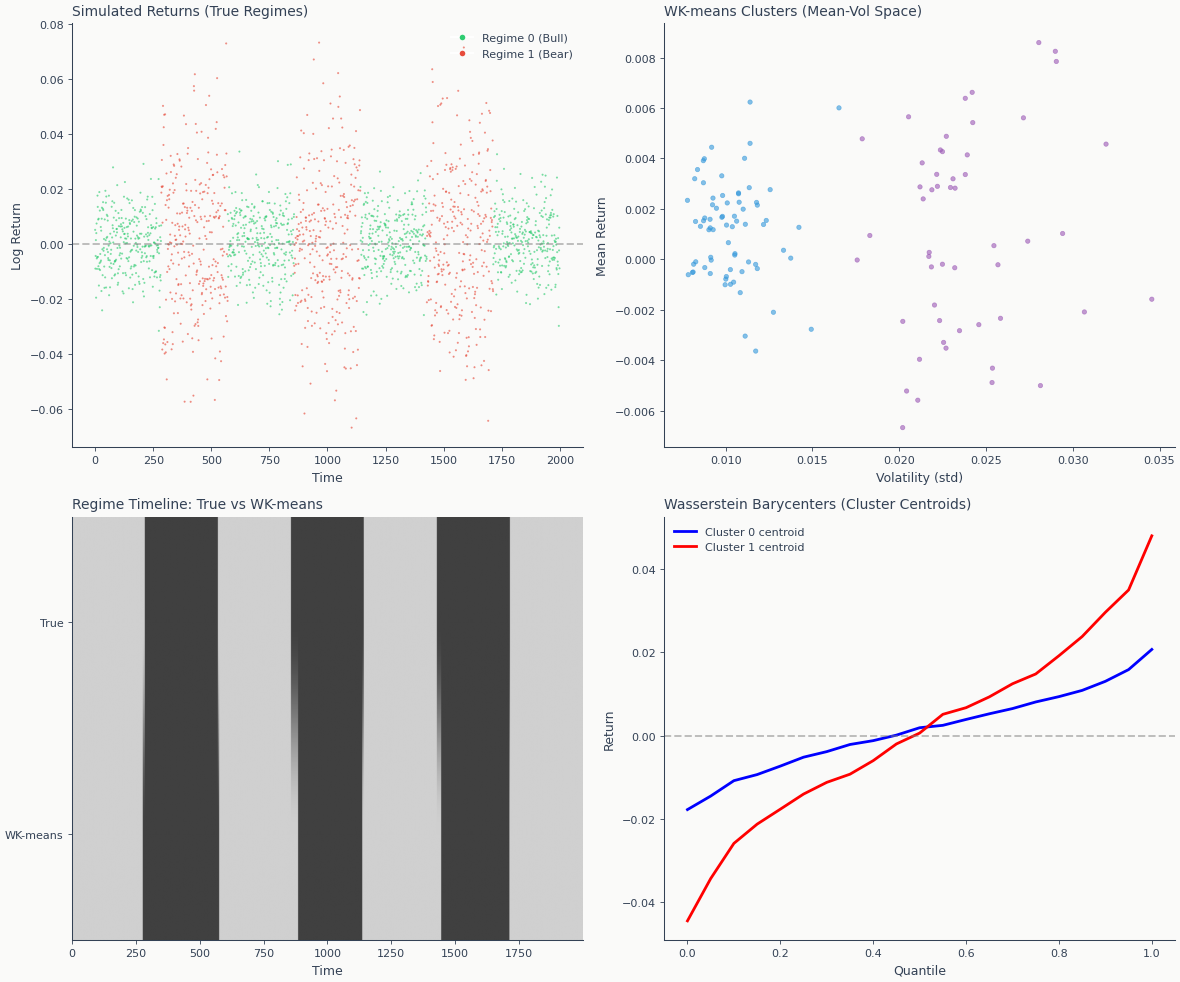

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Returns with true regime coloring
ax = axes[0, 0]
colors = np.where(true_regime == 0, "#2ecc71", "#e74c3c")
ax.scatter(range(len(returns)), returns, c=colors, s=1, alpha=0.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Log Return")
ax.set_title("Simulated Returns (True Regimes)")
ax.legend(
    handles=[
        plt.Line2D(
            [0], [0], marker="o", color="w", markerfacecolor="#2ecc71", label="Regime 0 (Bull)"
        ),
        plt.Line2D(
            [0], [0], marker="o", color="w", markerfacecolor="#e74c3c", label="Regime 1 (Bear)"
        ),
    ],
    loc="upper right",
)

# Plot 2: Mean-Variance projection with WK-means labels
ax = axes[0, 1]
means = lifted.segments.mean(axis=1)
stds = lifted.segments.std(axis=1)
wk_labels = results["WK-means"]["labels"]
colors = np.where(wk_labels == 0, "#3498db", "#9b59b6")
ax.scatter(stds, means, c=colors, s=10, alpha=0.6)
ax.set_xlabel("Volatility (std)")
ax.set_ylabel("Mean Return")
ax.set_title("WK-means Clusters (Mean-Vol Space)")

# Plot 3: Regime timeline comparison using imshow (swimlane style)
ax = axes[1, 0]
ts_labels = aggregate_segment_labels(lifted.starts, WINDOW_LEN, wk_labels, len(returns))

# Stack true vs predicted for swimlane comparison
regime_stack = np.vstack([true_regime.reshape(1, -1), ts_labels.reshape(1, -1)])
cmap_regime = ListedColormap(["#d0d0d0", "#404040"])  # Light gray = 0, dark gray = 1
ax.imshow(regime_stack, aspect="auto", cmap=cmap_regime, vmin=0, vmax=1)
ax.set_yticks([0, 1])
ax.set_yticklabels(["True", "WK-means"])
ax.set_xlabel("Time")
ax.set_title("Regime Timeline: True vs WK-means")

# Plot 4: Centroid comparison (quantile functions)
ax = axes[1, 1]
quantiles = np.linspace(0, 1, WINDOW_LEN)
ax.plot(quantiles, wk_result.centroids[0], "b-", linewidth=2, label="Cluster 0 centroid")
ax.plot(quantiles, wk_result.centroids[1], "r-", linewidth=2, label="Cluster 1 centroid")
ax.set_xlabel("Quantile")
ax.set_ylabel("Return")
ax.set_title("Wasserstein Barycenters (Cluster Centroids)")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Part 7: Application to Real Data

Apply WK-means to S&P 500 returns (1980-2025).

In [30]:
# Load S&P 500 index data (bundled with repository)
sp500_df = load_sp500_index().sort("timestamp")

# Compute log returns
prices = sp500_df["close"].to_numpy()
sp500_returns = np.log(prices[1:] / prices[:-1])
sp500_dates = sp500_df["timestamp"].to_numpy()[1:]

print(f"Loaded {len(sp500_returns):,} daily S&P 500 returns")
print(f"Date range: {sp500_dates[0]} to {sp500_dates[-1]}")

# Lift and cluster
real_lifted = lift_stream(sp500_returns, window_len=WINDOW_LEN, overlap=OVERLAP)
print(f"Created {real_lifted.segments.shape[0]} segments of length {WINDOW_LEN}")

real_wk = WassersteinKMeans1D(n_clusters=2, p=1.0, n_init=10, random_state=RANDOM_STATE)
real_result = real_wk.fit(real_lifted.sorted_segments)

print(f"Cluster sizes: {np.bincount(real_result.labels)}")

# Identify which cluster is high-vol
cluster_vols = [real_lifted.segments[real_result.labels == i].std() for i in range(2)]
high_vol_cluster = int(np.argmax(cluster_vols))
low_vol_cluster = 1 - high_vol_cluster
print(f"High-volatility cluster: {high_vol_cluster} (vol={cluster_vols[high_vol_cluster]:.4f})")
print(f"Low-volatility cluster: {low_vol_cluster} (vol={cluster_vols[low_vol_cluster]:.4f})")

Loaded 11,588 daily S&P 500 returns
Date range: 1980-01-03 to 2025-12-31
Created 723 segments of length 21
Cluster sizes: [522 201]
High-volatility cluster: 1 (vol=0.0179)
Low-volatility cluster: 0 (vol=0.0074)


### Regime Statistics

Show that the clusters capture meaningfully different market conditions.

In [31]:
# Compute statistics per regime
ts_labels = aggregate_segment_labels(
    real_lifted.starts, WINDOW_LEN, real_result.labels, len(sp500_returns)
)

regime_stats = []
for regime in [low_vol_cluster, high_vol_cluster]:
    mask = ts_labels == regime
    regime_returns = sp500_returns[mask]
    n_days = mask.sum()
    pct_time = 100 * n_days / len(sp500_returns)

    # Annualized metrics (252 trading days)
    ann_return = 252 * regime_returns.mean() * 100
    ann_vol = np.sqrt(252) * regime_returns.std() * 100
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    # Drawdown of compounded regime-only returns (bounded by -100%).
    cum = np.cumprod(1 + regime_returns)
    peak = np.maximum.accumulate(cum)
    dd = ((cum - peak) / peak).min() * 100

    regime_name = "Low-Vol" if regime == low_vol_cluster else "High-Vol"
    regime_stats.append(
        {
            "Regime": regime_name,
            "Days": n_days,
            "% Time": f"{pct_time:.1f}%",
            "Ann. Return": f"{ann_return:+.1f}%",
            "Ann. Vol": f"{ann_vol:.1f}%",
            "Sharpe": f"{sharpe:.2f}",
            "Max DD": f"{dd:.1f}%",
        }
    )

stats_df = pl.DataFrame(regime_stats)
stats_df

Regime,Days,% Time,Ann. Return,Ann. Vol,Sharpe,Max DD
str,i64,str,str,str,str,str
"""Low-Vol""",8667,"""74.8%""","""+18.9%""","""12.0%""","""1.57""","""-31.0%"""
"""High-Vol""",2921,"""25.2%""","""-20.1%""","""29.0%""","""-0.69""","""-95.1%"""


**Interpretation**: The low-vol regime shows higher annualized returns with
substantially lower volatility, producing a superior Sharpe ratio — the classic
"volatility drag" effect. High-vol periods have deeper drawdowns and may
exhibit negative mean returns. This regime asymmetry is why regime-conditional
position sizing (reduce exposure in high-vol) captures most of the portfolio
benefit from regime detection.

### ml4t-diagnostic: Distributional Distance Comparison

Our custom Wasserstein implementation above operates on sorted quantiles of
windowed return distributions. `ml4t-diagnostic` provides `compute_wasserstein_distance()`
and `compute_psi()` (Population Stability Index) for comparing two samples.
We use them to measure inter-cluster divergence as a validation metric.

In [32]:
# Sample returns from each cluster
c0_returns = sp500_returns[ts_labels == low_vol_cluster]
c1_returns = sp500_returns[ts_labels == high_vol_cluster]

w_result = compute_wasserstein_distance(c0_returns, c1_returns)
psi_result = compute_psi(c0_returns, c1_returns)

print("=== ml4t-diagnostic: Inter-Cluster Divergence ===")
print(f"Wasserstein distance: {w_result.distance:.6f}")
print(f"Drifted: {w_result.drifted}")
print(f"PSI: {psi_result.psi:.4f} (alert level: {psi_result.alert_level})")
print()
print("PSI interpretation: <0.1 = stable, 0.1-0.2 = moderate shift, >0.2 = significant shift")

=== ml4t-diagnostic: Inter-Cluster Divergence ===
Wasserstein distance: 0.007385
Drifted: True
PSI: 0.5549 (alert level: red)

PSI interpretation: <0.1 = stable, 0.1-0.2 = moderate shift, >0.2 = significant shift


**Interpretation**: The Wasserstein distance between cluster return distributions
quantifies how different the two regimes are in terms of optimal transport cost.
PSI provides a complementary bin-based measure commonly used in production
model monitoring. Both metrics confirm that the WK-means clusters capture
meaningfully different market conditions.

### Swimlane Visualization

Four-panel view: regime timeline, cumulative returns, rolling volatility, and centroids.

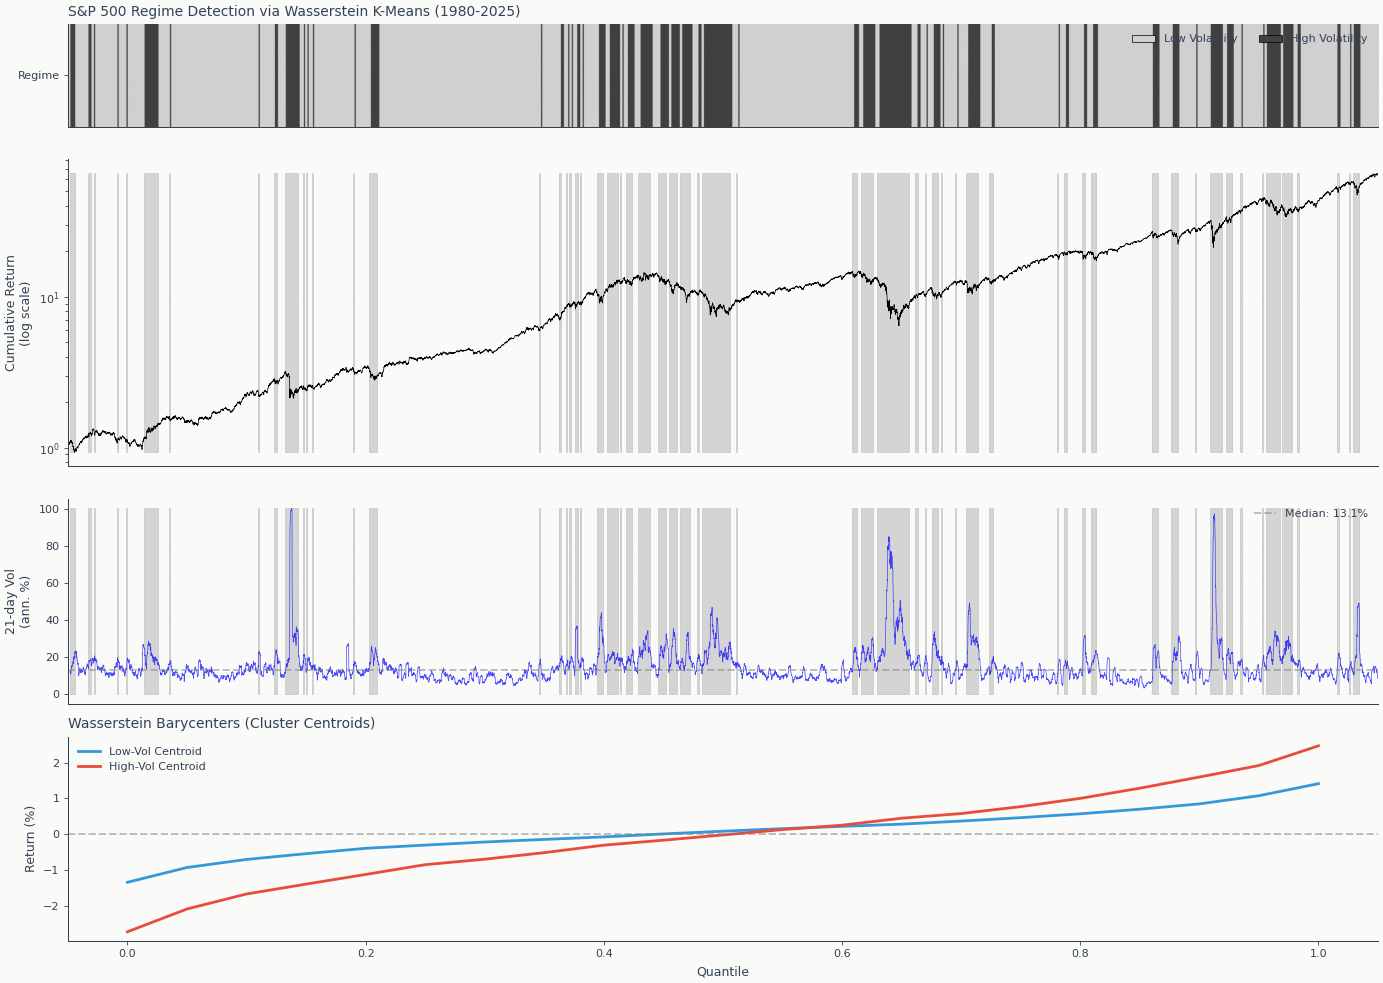

In [33]:
import matplotlib.dates as mdates

# Convert dates for matplotlib
dates_num = mdates.date2num(pd.to_datetime(sp500_dates))

fig, axes = plt.subplots(4, 1, figsize=(14, 10), height_ratios=[1, 3, 2, 2])
fig.subplots_adjust(hspace=0.05)

# Panel 1: Regime swimlane (imshow)
ax1 = axes[0]
labels_2d = ts_labels.reshape(1, -1)
# Map: low-vol=light gray, high-vol=dark gray
label_colors = np.where(labels_2d == high_vol_cluster, 1, 0)
cmap_regime = ListedColormap(["#d0d0d0", "#404040"])
ax1.imshow(
    label_colors, aspect="auto", cmap=cmap_regime, extent=[dates_num[0], dates_num[-1], 0, 1]
)
ax1.set_yticks([0.5])
ax1.set_yticklabels(["Regime"])
ax1.set_xlim(dates_num[0], dates_num[-1])
ax1.xaxis.set_visible(False)
ax1.set_title("S&P 500 Regime Detection via Wasserstein K-Means (1980-2025)")

# Add legend
legend_elements = [
    Patch(facecolor="#d0d0d0", edgecolor="black", label="Low Volatility"),
    Patch(facecolor="#404040", edgecolor="black", label="High Volatility"),
]
ax1.legend(handles=legend_elements, loc="upper right", ncol=2, fontsize=8)

# Panel 2: Cumulative returns (log scale)
ax2 = axes[1]
cum_returns = np.exp(np.cumsum(sp500_returns))
ax2.semilogy(dates_num, cum_returns, "k-", linewidth=0.5)
ax2.set_ylabel("Cumulative Return\n(log scale)")
ax2.set_xlim(dates_num[0], dates_num[-1])
ax2.xaxis.set_visible(False)
ax2.grid(True, alpha=0.3)

# Shade high-vol periods
high_vol_mask = ts_labels == high_vol_cluster
ax2.fill_between(
    dates_num,
    cum_returns.min(),
    cum_returns.max(),
    where=high_vol_mask,
    alpha=0.2,
    color="#404040",
)

# Panel 3: Rolling volatility (21-day)
ax3 = axes[2]
roll_vol = pd.Series(sp500_returns).rolling(21).std() * np.sqrt(252) * 100
ax3.plot(dates_num, roll_vol.values, "b-", linewidth=0.5, alpha=0.7)
ax3.axhline(
    roll_vol.median(),
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Median: {roll_vol.median():.1f}%",
)
ax3.set_ylabel("21-day Vol\n(ann. %)")
ax3.set_xlim(dates_num[0], dates_num[-1])
ax3.xaxis.set_visible(False)
ax3.legend(loc="upper right", fontsize=8)
ax3.grid(True, alpha=0.3)

# Shade high-vol periods
ax3.fill_between(dates_num, 0, roll_vol.max(), where=high_vol_mask, alpha=0.2, color="#404040")

# Panel 4: Wasserstein centroids (quantile functions)
ax4 = axes[3]
quantiles = np.linspace(0, 1, WINDOW_LEN)
ax4.plot(
    quantiles,
    real_result.centroids[low_vol_cluster] * 100,
    "#3498db",
    linewidth=2,
    label="Low-Vol Centroid",
)
ax4.plot(
    quantiles,
    real_result.centroids[high_vol_cluster] * 100,
    "#e74c3c",
    linewidth=2,
    label="High-Vol Centroid",
)
ax4.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax4.set_xlabel("Quantile")
ax4.set_ylabel("Return (%)")
ax4.legend(loc="upper left", fontsize=8)
ax4.set_title("Wasserstein Barycenters (Cluster Centroids)", fontsize=10)
ax4.grid(True, alpha=0.3)

# Format x-axis for date panels
for ax in [ax1, ax2, ax3]:
    ax.xaxis_date()

plt.tight_layout()
plt.show()

## Feature Extraction

Construct the three features listed in the chapter's feature catalog:
`wasserstein_cluster`, `cluster_distance`, and `tail_divergence`.

In [34]:
# 1. wasserstein_cluster: cluster assignment at each timestamp
wasserstein_cluster = ts_labels.copy()

# 2. cluster_distance: Wasserstein distance from each window to its assigned centroid
segment_distances = np.zeros(real_lifted.sorted_segments.shape[0])
for i, (seg, lab) in enumerate(zip(real_lifted.sorted_segments, real_result.labels, strict=False)):
    segment_distances[i] = wasserstein_distance_1d(seg, real_result.centroids[lab], p=1.0)

# Aggregate segment-level distances to timestamp-level (equal-weighted average)
# Each timestamp may be covered by multiple overlapping windows; accumulate
# sum and count, then divide for a proper average
ts_distance_sum = np.zeros(len(sp500_returns))
ts_distance_count = np.zeros(len(sp500_returns))
for start, dist in zip(real_lifted.starts, segment_distances, strict=False):
    end = min(start + WINDOW_LEN, len(sp500_returns))
    ts_distance_sum[start:end] += dist
    ts_distance_count[start:end] += 1

ts_cluster_distance = np.where(ts_distance_count > 0, ts_distance_sum / ts_distance_count, np.nan)

In [35]:
# 3. tail_divergence: difference between Wasserstein and moment-based cluster assignment
# Moment-based clustering uses mean and variance only
mk_real = fit_moment_kmeans(
    real_lifted.segments, n_clusters=2, n_moments=2, random_state=RANDOM_STATE
)
moment_ts_labels = aggregate_segment_labels(
    real_lifted.starts, WINDOW_LEN, mk_real.labels, len(sp500_returns)
)
# Align labels: ensure both methods use the same convention (high-vol = 1)
moment_vols = [sp500_returns[moment_ts_labels == i].std() for i in range(2)]
moment_high_vol = int(np.argmax(moment_vols))
if moment_high_vol != high_vol_cluster:
    moment_ts_labels = 1 - moment_ts_labels

# tail_divergence = 1 where methods disagree (distributional shape matters)
tail_divergence = (wasserstein_cluster != moment_ts_labels).astype(np.float64)

# Combine into feature DataFrame
feature_df = pl.DataFrame(
    {
        "timestamp": sp500_dates,
        "wasserstein_cluster": wasserstein_cluster,
        "cluster_distance": ts_cluster_distance,
        "tail_divergence": tail_divergence,
    }
)

print(f"Cluster distribution: {np.bincount(wasserstein_cluster)}")
print(f"Mean cluster distance: {np.nanmean(ts_cluster_distance):.6f}")
print(f"Tail divergence rate: {tail_divergence.mean():.1%} of days")
feature_df.tail(5)

Cluster distribution: [8667 2921]
Mean cluster distance: 0.002839
Tail divergence rate: 18.6% of days


timestamp,wasserstein_cluster,cluster_distance,tail_divergence
date,i64,f64,f64
2025-12-24,0,NaN,0.0
2025-12-26,0,NaN,0.0
2025-12-29,0,NaN,0.0
2025-12-30,0,NaN,0.0
2025-12-31,0,NaN,0.0


`tail_divergence` flags periods where Wasserstein and moment-based methods
disagree — indicating that distributional shape (tails, skewness) rather than
just mean/variance is driving the regime classification. High tail divergence
signals potential hedging demand.

## Summary

**Key findings from this notebook:**

1. **Wasserstein k-means** captures distributional shape, not just moments
2. The **stream lift** converts time series into a clustering problem on distributions
3. **MMD validation** provides a model-free assessment of cluster quality
4. WK-means often achieves **better ARI** when distributions differ in shape (tails, skewness)
5. For simple mean-variance regime changes, moment methods may perform comparably

**When to use WK-means over traditional methods:**
- Regime changes involve tail behavior or higher moments
- You want a distribution-aware distance metric
- Interpretable centroids as return quantile functions

**Reference**: Horvath et al. (2021) "Clustering Market Regimes Using the Wasserstein Distance"

**Previous**: `11_hmm_regimes` for parametric regime detection (HMM, MS-AR).
**Next**: `13_regime_as_feature` for integrating regime features into ML pipelines.